In [1]:
import os
import pandas as pd
import numpy as np
import pyomo.environ as pyo
from IPython.display import display


In [2]:
CSV_FILE = "berlin-tram-2024 (5).csv"


## Load and inspect the data


In [3]:
raw = pd.read_csv(CSV_FILE, header=None)

print("CSV shape:", raw.shape)
display(raw.head(10))


CSV shape: (24, 23)


,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,route,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,M1,M2,M4,M5,M6,M8,M10,12.0,M13,...,21.0,27.0,37.0,50.0,60.0,61.0,62.0,63.0,67.0,68.0
2,M1,1,NaN,NaN,1,NaN,1,1,1.0,1,...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
3,M2,NaN,1,1,1,1,1,1,1.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,M4,NaN,NaN,1,1,1,1,1,1.0,1,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,M5,NaN,NaN,NaN,1,1,1,1,NaN,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,M6,NaN,NaN,NaN,NaN,1,1,1,NaN,1,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,M8,NaN,NaN,NaN,NaN,NaN,1,1,1.0,1,...,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,M10,NaN,NaN,NaN,NaN,NaN,NaN,1,1.0,1,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Extract the 22 × 22 conflict matrix


In [4]:
EXPECTED_ROUTES = 22

official_routes = [
    "M1", "M2", "M4", "M5", "M6", "M8",
    "M10", "12", "M13", "16", "M17", "18",
    "21", "27", "37", "50", "60", "61",
    "62", "63", "67", "68"
]

# Shape: (22, 22) — plain matrix
# Shape: (23, 23) — one header row+col with labels
# Shape: (24, 23) — two header rows ("route" row + label row) + label col
if raw.shape == (EXPECTED_ROUTES, EXPECTED_ROUTES):
    route_names = official_routes.copy()
    matrix_df = raw.copy()
elif raw.shape == (EXPECTED_ROUTES + 1, EXPECTED_ROUTES + 1):
    route_names = raw.iloc[1:, 0].astype(str).str.strip().tolist()
    matrix_df = raw.iloc[1:, 1:].copy()
elif raw.shape == (EXPECTED_ROUTES + 2, EXPECTED_ROUTES + 1):
    route_names = raw.iloc[2:, 0].astype(str).str.strip().tolist()
    matrix_df = raw.iloc[2:, 1:].copy()
else:
    raise ValueError(
        f"Unexpected CSV dimensions: {raw.shape}. "
        "Expected 22x22, 23x23, or 24x23."
    )

conflict_matrix = matrix_df.apply(
    pd.to_numeric, errors="coerce"
).fillna(0).to_numpy()

if conflict_matrix.shape != (EXPECTED_ROUTES, EXPECTED_ROUTES):
    raise ValueError(
        f"Expected a 22x22 matrix, got {conflict_matrix.shape}."
    )

print("Number of routes:", len(route_names))
print("Matrix shape:", conflict_matrix.shape)

display(pd.DataFrame(
    conflict_matrix.astype(int),
    index=route_names,
    columns=route_names
))


Number of routes: 22
Matrix shape: (22, 22)


,M1,M2,M4,M5,M6,M8,M10,12,M13,16,...,21,27,37,50,60,61,62,63,67,68
M1,1,0,0,1,0,1,1,1,1,0,...,0,0,0,1,0,0,0,0,0,0
M2,0,1,1,1,1,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
M4,0,0,1,1,1,1,1,1,1,0,...,0,1,0,0,0,0,0,0,0,0
M5,0,0,0,1,1,1,1,0,1,1,...,0,0,0,0,0,0,0,0,0,0
M6,0,0,0,0,1,1,1,0,1,1,...,0,1,0,0,0,0,0,0,0,0
M8,0,0,0,0,0,1,1,1,1,1,...,1,1,1,0,0,0,0,0,0,0
M10,0,0,0,0,0,0,1,1,1,0,...,1,0,0,0,0,0,0,0,0,0
12,0,0,0,0,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
M13,0,0,0,0,0,0,0,0,1,1,...,1,0,0,1,0,0,0,0,0,0
16,0,0,0,0,0,0,0,0,0,1,...,1,1,0,0,0,0,0,0,0,0


## Build the conflict graph


In [5]:
routes = list(range(len(route_names)))

if np.array_equal(conflict_matrix, conflict_matrix.T):
    print("✓ Conflict matrix is symmetric.")
else:
    print("⚠ Matrix is not symmetric; using the upper triangle for conflicts.")

if np.all(np.diag(conflict_matrix) == 0):
    print("✓ Diagonal contains zeros.")
else:
    print("⚠ Diagonal contains non-zero entries.")

edges = []

for i in routes:
    for j in range(i + 1, len(routes)):
        if conflict_matrix[i, j] > 0 or conflict_matrix[j, i] > 0:
            edges.append((i, j))

print("Number of routes:", len(routes))
print("Number of conflict edges:", len(edges))


⚠ Matrix is not symmetric; using the upper triangle for conflicts.
⚠ Diagonal contains non-zero entries.
Number of routes: 22
Number of conflict edges: 81


## Pyomo MILP formulation


In [6]:
model = pyo.ConcreteModel(name="BerlinTramGraphColoring")

# Routes and candidate colors.
model.R = pyo.RangeSet(0, len(routes) - 1)
model.C = pyo.RangeSet(0, len(routes) - 1)

# x[r,c] = 1 when route r receives color c.
model.x = pyo.Var(model.R, model.C, domain=pyo.Binary)

# y[c] = 1 when color c is used.
model.y = pyo.Var(model.C, domain=pyo.Binary)

# Exactly one color per route.
def one_color_rule(model, r):
    return sum(model.x[r, c] for c in model.C) == 1

model.one_color = pyo.Constraint(
    model.R,
    rule=one_color_rule
)

# Conflicting routes cannot share a color.
model.conflict_constraints = pyo.ConstraintList()

for i, j in edges:
    for c in model.C:
        model.conflict_constraints.add(
            model.x[i, c] + model.x[j, c] <= 1
        )

# Link route assignments to active colors.
def color_activation_rule(model, r, c):
    return model.x[r, c] <= model.y[c]

model.color_activation = pyo.Constraint(
    model.R,
    model.C,
    rule=color_activation_rule
)

# Minimize the number of active colors.
model.objective = pyo.Objective(
    expr=sum(model.y[c] for c in model.C),
    sense=pyo.minimize
)

print("Model created successfully.")
print("Variables:", len(routes) * len(routes) + len(routes))
print("Conflict constraints:", len(model.conflict_constraints))


Model created successfully.
Variables: 506
Conflict constraints: 1782


## Solve with CBC


In [7]:
solver = pyo.SolverFactory("cbc")

if not solver.available():
    raise RuntimeError(
        "CBC is not available. Install CBC or configure its executable path."
    )

result = solver.solve(model, tee=False)

print("Solver status:", result.solver.status)
print("Termination condition:", result.solver.termination_condition)


Solver status: ok
Termination condition: optimal


In [8]:
if result.solver.termination_condition != pyo.TerminationCondition.optimal:
    raise RuntimeError(
        "CBC did not return an optimal solution. "
        f"Termination condition: {result.solver.termination_condition}"
    )

optimal_colors = int(round(pyo.value(model.objective)))

print("✓ Optimal solution found.")
print("Minimum number of colors:", optimal_colors)


✓ Optimal solution found.
Minimum number of colors: 7


## Extract the optimal route-color assignment


In [9]:
assignments = []

for r in model.R:
    assigned_color = None

    for c in model.C:
        if pyo.value(model.x[r, c]) > 0.5:
            assigned_color = int(c) + 1
            break

    if assigned_color is None:
        raise RuntimeError(
            f"Route {route_names[int(r)]} has no assigned color."
        )

    assignments.append({
        "Route": route_names[int(r)],
        "Color_ID": assigned_color
    })

assignment_df = pd.DataFrame(assignments)

color_names = [
    "Yellow", "Green", "Blue", "Orange", "Pink", "Grey",
    "Red", "Brown", "Deep Blue", "Purple", "Cyan", "Magenta",
    "Lime", "Teal", "Navy", "Gold", "Maroon", "Olive",
    "Violet", "Turquoise", "Coral", "Indigo"
]

assignment_df["Color"] = assignment_df["Color_ID"].map(
    lambda c: color_names[c - 1]
)

assignment_df = assignment_df.sort_values(
    ["Color_ID", "Route"]
).reset_index(drop=True)

display(assignment_df)


,Route,Color_ID,Color
0,63,3,Blue
1,M1,3,Blue
2,M17,3,Blue
3,M4,3,Blue
4,18,7,Red
5,27,7,Red
6,50,7,Red
7,M10,7,Red
8,68,8,Brown
9,M8,8,Brown


## Group routes by color


In [10]:
color_groups = (
    assignment_df
    .groupby(["Color_ID", "Color"])["Route"]
    .apply(list)
    .reset_index()
)

for _, row in color_groups.iterrows():
    print(
        f"Color {row['Color_ID']} ({row['Color']}): "
        + ", ".join(row["Route"])
    )


Color 3 (Blue): 63, M1, M17, M4
Color 7 (Red): 18, 27, 50, M10
Color 8 (Brown): 68, M8
Color 13 (Lime): 12, 67, M6
Color 16 (Gold): 21, 61, M5
Color 21 (Coral): 37, 62, M13
Color 22 (Indigo): 16, 60, M2


## Independent solution validation


In [11]:
route_to_color = dict(
    zip(assignment_df["Route"], assignment_df["Color_ID"])
)

assert len(assignment_df) == len(route_names)
assert assignment_df["Route"].nunique() == len(route_names)
assert assignment_df["Color_ID"].notna().all()

violations = []

for i, j in edges:
    ri = route_names[i]
    rj = route_names[j]

    if route_to_color[ri] == route_to_color[rj]:
        violations.append((ri, rj))

if violations:
    print("✗ Invalid coloring")
    for pair in violations:
        print("Conflict:", pair)
else:
    print("✓ Valid coloring")
    print("✓ Every route has exactly one color")
    print("✓ No conflicting routes share a color")


✓ Valid coloring
✓ Every route has exactly one color
✓ No conflicting routes share a color


## Final optimization summary


In [12]:
print("=" * 65)
print("BERLIN TRAM NETWORK — GRAPH COLORING OPTIMIZATION")
print("=" * 65)
print(f"Routes                  : {len(route_names)}")
print(f"Conflict edges          : {len(edges)}")
print(f"Minimum colors required : {optimal_colors}")
print("Solver                  : CBC")
print("Formulation             : Binary MILP")
print("Solution status         : Optimal")
print("=" * 65)

for _, row in color_groups.iterrows():
    print(
        f"{row['Color']:<12} -> " + ", ".join(row["Route"])
    )


BERLIN TRAM NETWORK — GRAPH COLORING OPTIMIZATION
Routes                  : 22
Conflict edges          : 81
Minimum colors required : 7
Solver                  : CBC
Formulation             : Binary MILP
Solution status         : Optimal
Blue         -> 63, M1, M17, M4
Red          -> 18, 27, 50, M10
Brown        -> 68, M8
Lime         -> 12, 67, M6
Gold         -> 21, 61, M5
Coral        -> 37, 62, M13
Indigo       -> 16, 60, M2


## Optional visualization


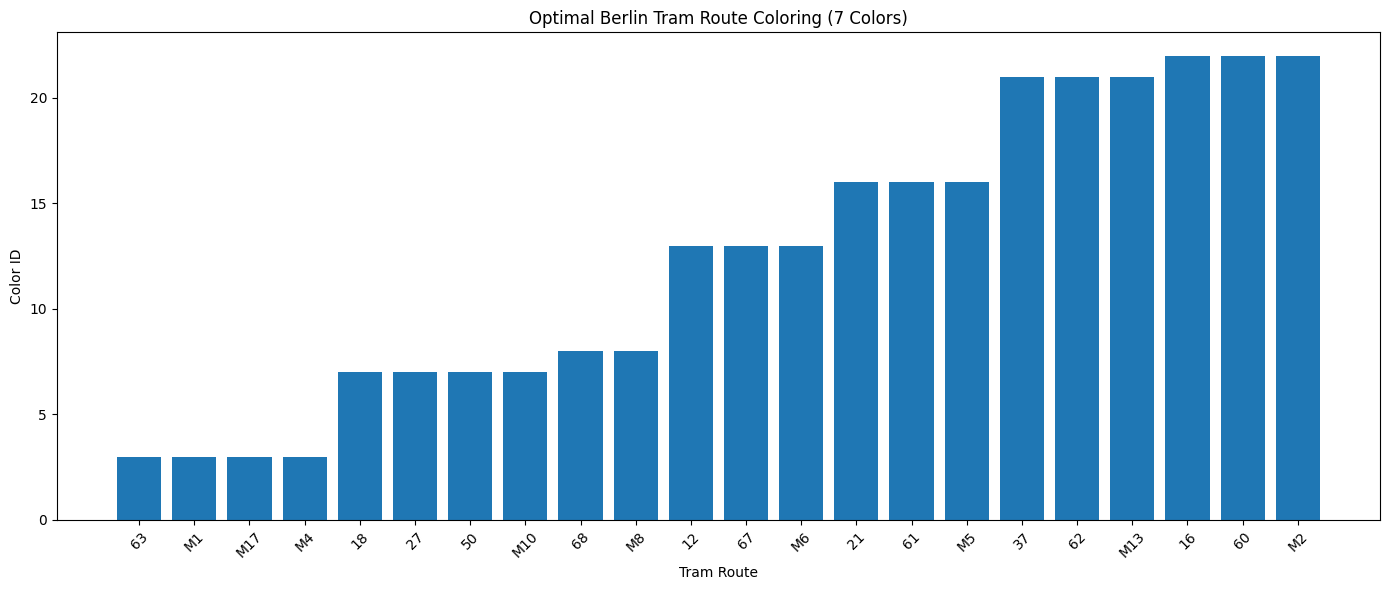

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.bar(assignment_df["Route"], assignment_df["Color_ID"])
plt.xlabel("Tram Route")
plt.ylabel("Color ID")
plt.title(
    f"Optimal Berlin Tram Route Coloring ({optimal_colors} Colors)"
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
